# Cosmic Intelligence Lab

## Deep Galaxy Explorer — Study 001

# Notebook 007 — Explore the Astronomical Catalog

---

## Research Question

What can we learn about the population of detected astronomical sources by exploring their measured properties?

---

## Objectives

- Load the astronomical source catalog
- Examine catalog structure and available measurements
- Explore the distributions of source brightness and size
- Identify the brightest and largest detected objects
- Visualize relationships between source properties
- Prepare the catalog for future machine learning analyses

In [1]:
# Cell 2 - Import Required Libraries ===========================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from astropy.table import Table

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Cell 3 - Load Astronomical Catalog ===========================

catalog_file = Path("../data/catalogs/source_catalog.ecsv")

catalog = Table.read(
    catalog_file,
    format="ascii.ecsv"
)

print("Astronomical catalog loaded successfully.")
print(f"Number of detected sources : {len(catalog)}")

Astronomical catalog loaded successfully.
Number of detected sources : 95


In [3]:
# Cell 4 - Examine Catalog Structure ===========================

print(f"Rows    : {len(catalog)}")
print(f"Columns : {len(catalog.colnames)}")

print("\nAvailable measurements:\n")

catalog.colnames

Rows    : 95
Columns : 19

Available measurements:



['label',
 'x_centroid',
 'y_centroid',
 'sky_centroid',
 'bbox_xmin',
 'bbox_xmax',
 'bbox_ymin',
 'bbox_ymax',
 'area',
 'semimajor_axis',
 'semiminor_axis',
 'orientation',
 'eccentricity',
 'min_value',
 'max_value',
 'segment_flux',
 'segment_flux_err',
 'kron_flux',
 'kron_flux_err']

In [4]:
# Cell 5 - Preview the First Ten Sources =======================

catalog[:10]

label,x_centroid,y_centroid,sky_centroid,bbox_xmin,bbox_xmax,bbox_ymin,bbox_ymax,area,semimajor_axis,semiminor_axis,orientation,eccentricity,min_value,max_value,segment_flux,segment_flux_err,kron_flux,kron_flux_err
,,,,,,,,pix2,pix,pix,deg,,,,,,,
int32,float64,float64,object,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,1011.1558648801878,1.9725426798241823,None,1007,1013,0,6,24.0,2.1532985095548427,1.4546436878746936,59.68625869106634,0.7373214628932244,1.7645800113677979,8.897390365600586,103.97923684120178,nan,97.36517517204038,nan
2,736.7927696461153,11.42845451172875,None,735,739,10,13,16.0,1.0425375485147124,0.8473819282730207,30.763603254853948,0.5825329240047639,0.6191791296005249,2.931279420852661,19.497517228126526,nan,27.61112048642445,nan
3,622.1228461046784,18.82930759190662,None,621,624,17,21,16.0,0.8541513400365031,0.7580456582502352,277.7009772993434,0.4608385055033623,0.5621078014373779,12.082280158996582,31.58135676383972,nan,34.42159785873663,nan
4,121.18956760830898,31.32029442469728,None,120,122,30,32,6.0,0.6440643877584695,0.5514238892637224,294.4995327788689,0.516706370668758,0.5479127168655396,2.140134334564209,6.465743601322174,nan,12.983454270407863,nan
5,529.4126604123757,79.48980618510005,None,525,532,76,84,32.0,2.2941649471403283,1.4005674373639603,303.90657994640236,0.7920230641969821,0.5414181351661682,1.639194130897522,24.018874406814575,nan,95.29540050691291,nan
6,540.0202264635453,79.18836128348309,None,538,542,77,81,15.0,1.063488324717736,0.9223128857493856,271.8012506450832,0.497868595189019,0.5437135696411133,1.8551239967346191,12.340121269226074,nan,60.14385696013455,nan
7,809.1891942549092,84.74331593280078,None,808,811,83,86,13.0,1.0771237638461464,0.7989851718607586,45.38350344446989,0.6706470897789912,0.5706205368041992,1.5475101470947266,11.399610340595245,nan,17.897842162107004,nan
8,620.784680169983,90.4208343944767,None,619,622,89,92,10.0,1.13510003434925,0.6721785777757441,318.5683560480159,0.805808924882241,0.5459803342819214,0.6996515989303589,6.043212354183197,nan,46.91598378461046,nan


In [5]:
# Cell 6 - Catalog Summary Statistics ==========================

print("=" * 60)
print("Astronomical Catalog Summary")
print("=" * 60)

print(f"Total detected sources : {len(catalog)}")

print()

print(f"Brightest source (flux) : {catalog['segment_flux'].max():.2f}")
print(f"Faintest source (flux)  : {catalog['segment_flux'].min():.2f}")

print()

print(f"Largest source (area)   : {catalog['area'].max():.1f} pixels²")
print(f"Smallest source (area)  : {catalog['area'].min():.1f} pixels²")

print()

print(f"Mean source flux        : {np.mean(catalog['segment_flux']):.2f}")
print(f"Median source flux      : {np.median(catalog['segment_flux']):.2f}")

print()

print(f"Mean source area        : {np.mean(catalog['area']):.2f} pixels²")
print(f"Median source area      : {np.median(catalog['area']):.2f} pixels²")

Astronomical Catalog Summary
Total detected sources : 95

Brightest source (flux) : 6329.18
Faintest source (flux)  : 3.00

Largest source (area)   : 549.0 pixels²
Smallest source (area)  : 5.0 pixels²

Mean source flux        : 188.78
Median source flux      : 17.00

Mean source area        : 38.21 pixels²
Median source area      : 14.00 pixels²


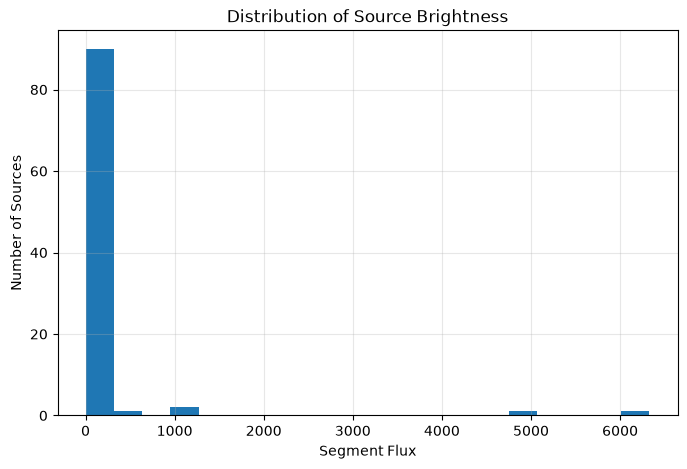

In [6]:
# Cell 7 - Histogram of Source Brightness ======================

plt.figure(figsize=(8, 5))

plt.hist(
    catalog["segment_flux"],
    bins=20,
)

plt.title("Distribution of Source Brightness")

plt.xlabel("Segment Flux")

plt.ylabel("Number of Sources")

plt.grid(alpha=0.3)

plt.show()

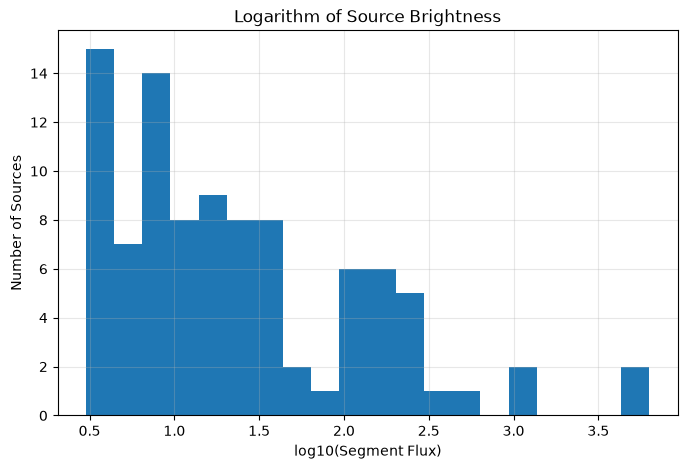

In [7]:
# Cell 8 - Logarithmic Brightness Distribution ================

plt.figure(figsize=(8,5))

plt.hist(
    np.log10(catalog["segment_flux"]),
    bins=20
)

plt.title("Logarithm of Source Brightness")

plt.xlabel("log10(Segment Flux)")

plt.ylabel("Number of Sources")

plt.grid(alpha=0.3)

plt.show()

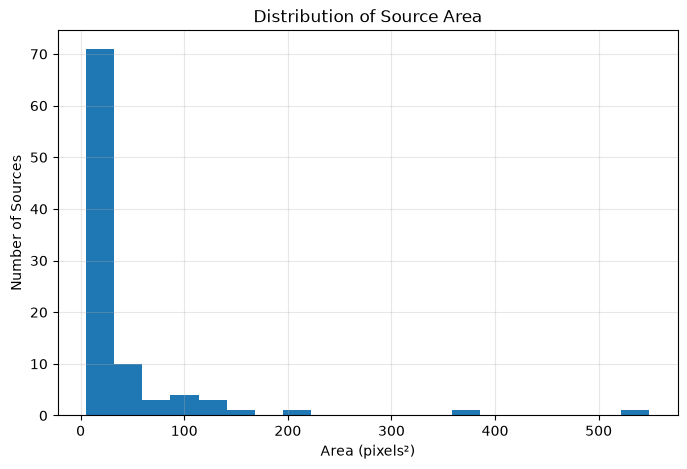

In [8]:
# Cell 9 - Distribution of Source Area =========================

plt.figure(figsize=(8, 5))

plt.hist(
    catalog["area"],
    bins=20
)

plt.title("Distribution of Source Area")

plt.xlabel("Area (pixels²)")

plt.ylabel("Number of Sources")

plt.grid(alpha=0.3)

plt.show()

### Scientific Interpretation – Source Area

The histogram shows the distribution of detected source sizes.

Most detected sources occupy relatively few pixels, indicating that the catalog
is dominated by compact astronomical objects. Only a small number of sources
cover large areas, corresponding to bright stars or extended galaxies.

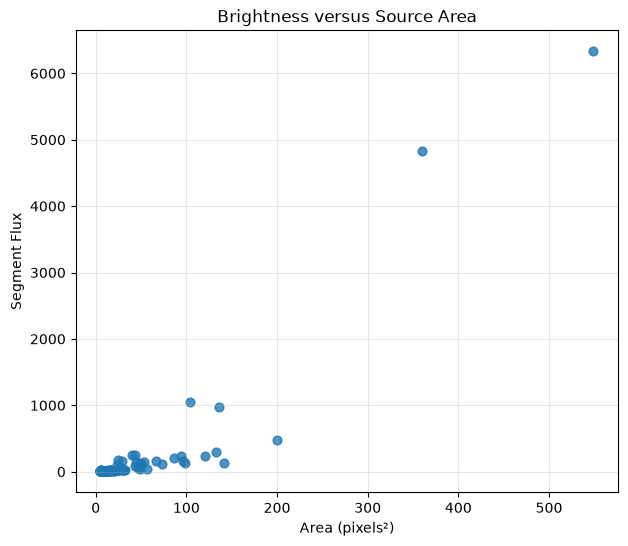

In [9]:
# Cell 10 - Brightness versus Area =============================

plt.figure(figsize=(7, 6))

plt.scatter(
    catalog["area"],
    catalog["segment_flux"],
    s=40,
    alpha=0.8
)

plt.title("Brightness versus Source Area")

plt.xlabel("Area (pixels²)")

plt.ylabel("Segment Flux")

plt.grid(alpha=0.3)

plt.show()

### Scientific Interpretation – Brightness versus Area

Each point represents one detected astronomical source.

This scatter plot allows us to investigate whether brighter objects also tend
to occupy larger areas on the detector. Such relationships can help distinguish
compact sources from extended galaxies and provide useful features for future
machine learning analyses.

In [1]:
# Cell 11 - Notebook Status ==================================

from datetime import datetime

print("=" * 60)
print("Notebook Status")
print("=" * 60)

print("Status    : PASS")
print("Notebook  : 07_explore_first_astronomical_catalog.ipynb")
print("Completed :", datetime.now().strftime("%Y-%m-%d %H:%M"))

Notebook Status
Status    : PASS
Notebook  : 07_explore_first_astronomical_catalog.ipynb
Completed : 2026-07-14 20:21
